## Threshold tuning

This notebook evaluates the impact of the classification threshold on
precision and recall for the selected models, using previously tuned
hyperparameters. The objective is to select a threshold that maximizes
recall under acceptable precision constraints.

In [42]:
import pandas as pd
import yaml
import mlflow
import numpy as np
from pathlib import Path
from datapipeline.config.mlflow_config import setup_mlflow
from mlflow.tracking import MlflowClient
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
import xgboost as xgb
from sklearn.metrics import (precision_recall_curve, 
                            auc,
                            PrecisionRecallDisplay,
                            precision_score,
                            recall_score)
import matplotlib.pyplot as plt

In [43]:
#loading config file
config_path = '../config.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

In [44]:
random_state = config["model_training"]["random_state"]
artifacts_dir = Path(config['threshold_tuning']['artifacts_path'])

# MLflow

In [45]:
client = MlflowClient()

In [46]:
experiment_name = config['pipeline']['experiment_name']
experiment = client.get_experiment_by_name(experiment_name)
experiment_id = experiment.experiment_id

In [47]:
setup_mlflow(experiment_name)

In [49]:
mlflow.end_run()
mlflow.start_run(run_name="Threshold_tuning")


<ActiveRun: >

# Load  Dataset

In [50]:
#only the dataset that was previously separated for training is being loaded
dataset_path = Path(config['feature_engineering']['train_path_feature_engineered'])
target_column = config['data']['target_column']

In [51]:
df = pd.read_parquet(dataset_path)

In [52]:
df_y = df[target_column]

In [53]:
df_x = df.drop(columns = ['Time', target_column])

In [54]:
x_train, x_test, y_train, y_test =  train_test_split(df_x, 
                                                     df_y, 
                                                     test_size=0.3, 
                                                     random_state=random_state,
                                                     stratify=df_y)

# Models

Models selected in the previous step:

- Catboost
- Extra Trees
- Xgboost

In [55]:
#Loading best hyperparameters from the previous notebook

def loading_hyperparameters(experiment_name: str, 
                            random_state: int,
                            tag: str,
                            tag_value: str) -> dict:
    '''
    Get the hyperparameters logged in a mlflow run

    Args:
        experiment_name (str): the name of the mlflow experiment
        random_state (int): the random_stare will be added to the model's hyperparameters
        tag (str): The tag of the run in mlflow
        tag_value (str): the tag value of the run in mlflow
    Returns:
        dict: a dict containing the hyperparameters of a model
        
    '''    
    
    client = MlflowClient()
    experiment = client.get_experiment_by_name(experiment_name)
    experiment_id = experiment.experiment_id
    
    experiment_ids = [experiment_id]
    runs = client.search_runs(
        experiment_ids = [experiment_id],
        filter_string = f"tags.{tag} = '{tag_value}'" 
    )
    run_id = runs[0].info.run_id
    run = mlflow.get_run(run_id)
    params = run.data.params
    params['random_state'] = random_state
    return params
    

In [56]:
catboost_hyperparameters = loading_hyperparameters(experiment_name=experiment_name,
                                                   random_state=random_state,
                                                   tag='model',
                                                   tag_value='catboost')

xgboost_hyperparameters = loading_hyperparameters(experiment_name=experiment_name,
                                                   random_state=random_state,
                                                   tag='model',
                                                   tag_value='xgboost')

extratrees_hyperparameters = loading_hyperparameters(experiment_name=experiment_name,
                                                   random_state=random_state,
                                                   tag='model',
                                                   tag_value='extratrees')



In [57]:
catboost_hyperparameters

{'l2_leaf_reg': '2.5294826646261614',
 'depth': '8',
 'iterations': '789',
 'learning_rate': '0.019726635731539422',
 'random_state': 42}

In [58]:
xgboost_hyperparameters

{'min_child_weight': '6',
 'colsample_bytree': '0.9853811651459768',
 'subsample': '0.6042699939440438',
 'scale_pos_weight': '6.732525161292896',
 'max_depth': '7',
 'n_estimators': '426',
 'learning_rate': '0.2073325667744343',
 'random_state': 42}

In [59]:
extratrees_hyperparameters

{'min_samples_leaf': '1',
 'max_features': '0.8349897996484641',
 'max_depth': '19',
 'min_samples_split': '7',
 'n_estimators': '707',
 'random_state': 42}

In [60]:
# The hyperparameters were saved in MLflow as strings and need to be converted back to integers or floats as appropriate.

def to_float(x):
    try:
        if '.' in x:
            return float(x)
        else:
            return int(x)
    except(TypeError, ValueError):
        return x

In [61]:
#converting the hyperparamenters
catboost_hyperparameters = {key:to_float(value) for key, value in catboost_hyperparameters.items()}
xgboost_hyperparameters = {key:to_float(value) for key, value in xgboost_hyperparameters.items()}
extratrees_hyperparameters = {key:to_float(value) for key, value in extratrees_hyperparameters.items()}

In [62]:
# instantiating the models
catboost = CatBoostClassifier(**catboost_hyperparameters)
xgboost = xgb.XGBClassifier(**xgboost_hyperparameters)
extratrees = ExtraTreesClassifier(**extratrees_hyperparameters)


## Catboost

In [63]:
# fitting the model
catboost.fit(x_train, y_train, verbose = False)

In [64]:
y_pred_proba_catboost = catboost.predict_proba(x_test)[:,1]

In [65]:
precision_cat, recall_cat, thresholds_cat = precision_recall_curve(
    y_test, y_pred_proba_catboost)

<Figure size 640x480 with 0 Axes>

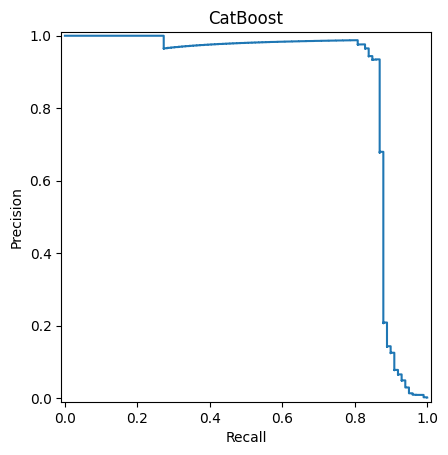

In [66]:
#plotting precision vs recall curve
plt.figure()
pr_display = PrecisionRecallDisplay(precision=precision_cat, 
                                    recall=recall_cat).plot()
plt.title('CatBoost')
file_name = 'precision_recall_catboost.png'
plt.savefig(artifacts_dir / file_name)
mlflow.log_artifact(artifacts_dir / file_name,
                    artifact_path='threshold_tuning')


In [67]:
#organizing the results in a pandas dataframe
results_catboost = dict({'Thresholds': thresholds_cat,
                         'Precision': precision_cat[:-1],
                         'Recall': recall_cat[:-1]})
results_catboost = pd.DataFrame(results_catboost)

In [68]:
results_catboost[(results_catboost['Recall']>0.8) & (results_catboost['Precision']>0.9)]

,Thresholds,Precision,Recall
58615,0.084089,0.905263,0.868687
58616,0.085792,0.914894,0.868687
58617,0.114858,0.924731,0.868687
58618,0.132857,0.934783,0.868687
58619,0.177191,0.934066,0.858586
58620,0.253097,0.933333,0.848485
58621,0.263061,0.943820,0.848485
58622,0.276070,0.943182,0.838384
58623,0.282578,0.954023,0.838384
58624,0.328032,0.965116,0.838384


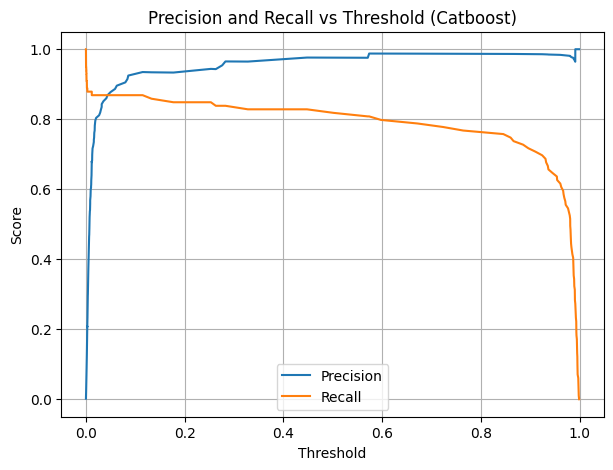

In [69]:
#plotting precision and recall vs threshold

plt.figure(figsize=(7, 5))
plt.plot(thresholds_cat, precision_cat[1:], label="Precision")
plt.plot(thresholds_cat, recall_cat[1:], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold (Catboost)")
plt.legend()
plt.grid(True)
file_name = 'precision_recall_threshold_catboost.png'
plt.savefig(artifacts_dir / file_name)
mlflow.log_artifact(artifacts_dir / file_name,
                    artifact_path='threshold_tuning')


## XgBoost

In [70]:
#fitting the model
xgboost.fit(x_train, y_train, verbose = False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9853811651459768, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2073325667744343,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=6, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=426, n_jobs=None,
              num_parallel_tree=None, ...)

In [71]:
y_pred_proba_xgboost = xgboost.predict_proba(x_test)[:,1]

In [72]:
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_test, y_pred_proba_xgboost)

<Figure size 640x480 with 0 Axes>

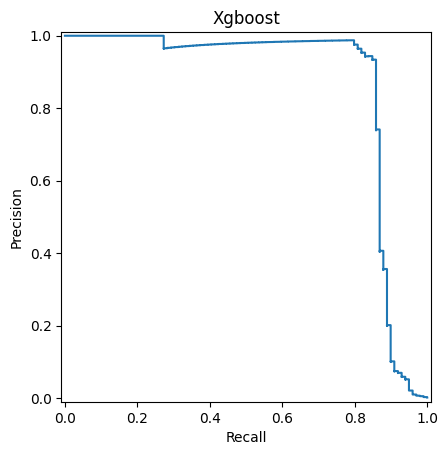

In [73]:
#plotting precision vs recall curve
plt.figure()
pr_display = PrecisionRecallDisplay(precision=precision_xgb, 
                                    recall=recall_xgb).plot()
plt.title('Xgboost')
file_name = 'precision_recall_xgboost.png'
plt.savefig(artifacts_dir / file_name)
mlflow.log_artifact(artifacts_dir / file_name,
                    artifact_path='threshold_tuning')
   

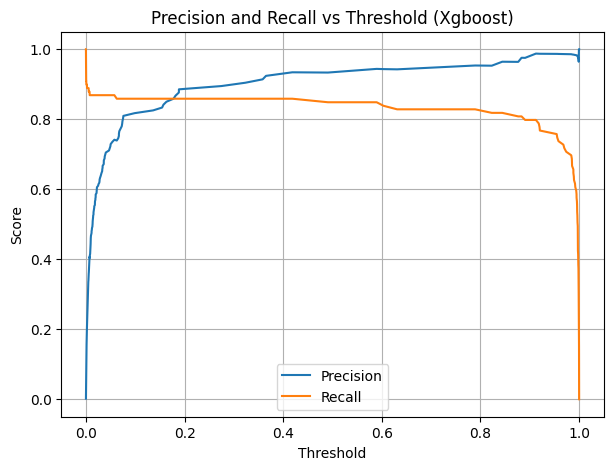

In [74]:
#plotting precision and recall vs threshold

plt.figure(figsize=(7, 5))
plt.plot(thresholds_xgb, precision_xgb[1:], label="Precision")
plt.plot(thresholds_xgb, recall_xgb[1:], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold (Xgboost)")
plt.legend()
plt.grid(True)
file_name = 'precision_recall_threshold_xgboost.png'
plt.savefig(artifacts_dir / file_name)
mlflow.log_artifact(artifacts_dir / file_name,
                    artifact_path='threshold_tuning')
  

In [75]:
results_xgboost = dict({'Thresholds': thresholds_xgb,
                         'Precision': precision_xgb[:-1],
                         'Recall': recall_xgb[:-1]})
results_xgboost = pd.DataFrame(results_xgboost)

In [76]:
results_xgboost[(results_xgboost['Recall']>0.8) & (results_xgboost['Precision']>0.9)]

,Thresholds,Precision,Recall
57486,0.358312,0.904255,0.858586
57487,0.365128,0.913978,0.858586
57488,0.418480,0.923913,0.858586
57489,0.490738,0.934066,0.858586
57490,0.589476,0.933333,0.848485
57491,0.603360,0.943820,0.848485
57492,0.630982,0.943182,0.838384
57493,0.789154,0.942529,0.828283
57494,0.822879,0.953488,0.828283
57495,0.844174,0.952941,0.818182


## Extra Trees

In [77]:
# fitting the model
extratrees.fit(x_train, y_train)

ExtraTreesClassifier(max_depth=19, max_features=0.8349897996484641,
                     min_samples_split=7, n_estimators=707, random_state=42)

In [78]:
y_pred_proba_extra = extratrees.predict_proba(x_test)[:,1]

In [79]:
precision_extra, recall_extra, thresholds_extra = precision_recall_curve(
    y_test, y_pred_proba_extra)

<Figure size 640x480 with 0 Axes>

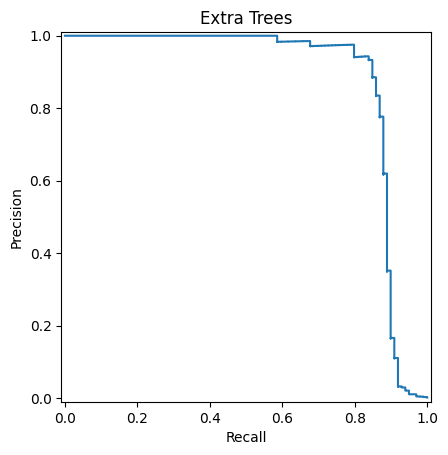

In [80]:
#plotting precision vs recall curve

plt.figure()
pr_display = PrecisionRecallDisplay(precision=precision_extra, 
                                    recall=recall_extra).plot()
plt.title('Extra Trees')
file_name = 'precision_recall_extratrees.png'
plt.savefig(artifacts_dir / file_name)
mlflow.log_artifact(artifacts_dir / file_name,
                    artifact_path='threshold_tuning')
     

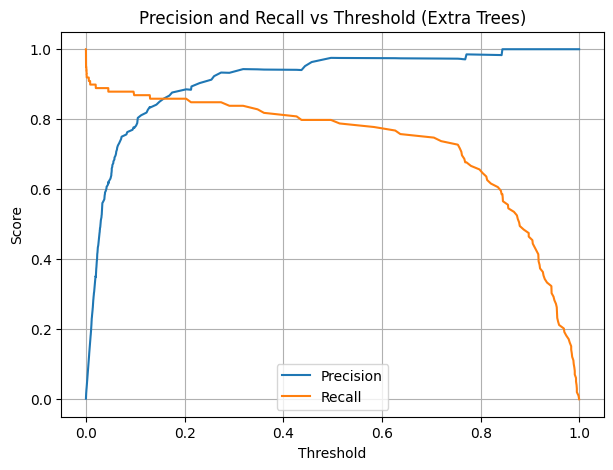

In [81]:
#plotting precision and recall vs threshold

plt.figure(figsize=(7, 5))

plt.plot(thresholds_extra, precision_extra[1:], label="Precision")
plt.plot(thresholds_extra, recall_extra[1:], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold (Extra Trees)")
plt.legend()
plt.grid(True)
file_name = 'precision_recall_threshold_extratrees.png'
plt.savefig(artifacts_dir / file_name)
mlflow.log_artifact(artifacts_dir / file_name,
                    artifact_path='threshold_tuning')
    

In [82]:
#organizing the results in a pandas dataframe

results_extra = dict({'Thresholds': thresholds_extra,
                         'Precision': precision_extra[:-1],
                         'Recall': recall_extra[:-1]})
results_extra = pd.DataFrame(results_extra)


In [83]:
results_extra[(results_extra['Recall']>0.8) & (results_extra['Precision']>0.9)]

,Thresholds,Precision,Recall
56345,0.254237,0.903226,0.848485
56346,0.259647,0.913043,0.848485
56347,0.273822,0.923077,0.848485
56348,0.290665,0.933333,0.848485
56349,0.318492,0.932584,0.838384
56350,0.347743,0.943182,0.838384
56351,0.360755,0.942529,0.828283
56352,0.426833,0.941860,0.818182
56353,0.436804,0.941176,0.808081


## Model Comparisson

In [84]:
# Comparing the results of the three models

Text(0.5, 1.0, 'CatBoost vs XgBoost vs ExtraTrees')

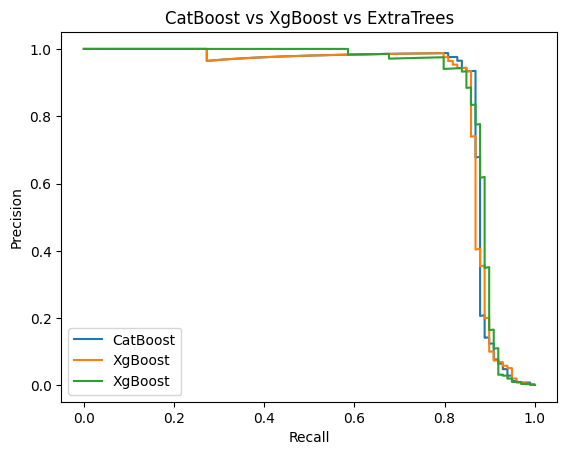

In [85]:
plt.figure()
plt.plot(recall_cat, precision_cat, label = 'CatBoost')
plt.plot(recall_xgb, precision_xgb, label = 'XgBoost')
plt.plot(recall_extra, precision_extra, label = 'XgBoost')

plt.xlabel("Recall")
plt.ylabel('Precision')
plt.legend()
plt.title('CatBoost vs XgBoost vs ExtraTrees')


In [86]:
area_catboost = auc(recall_cat, precision_cat)
area_xgboost = auc(recall_xgb, precision_xgb)
area_extratrees = auc(recall_extra, precision_extra)

print(f'AUC-PR CatBoost: {area_catboost}')
print(f'AUC-PR XgBoost: {area_xgboost}')
print(f'AUC-PR Extra trees: {area_extratrees}')


AUC-PR CatBoost: 0.8695079248974692
AUC-PR XgBoost: 0.8662979045634658
AUC-PR Extra trees: 0.8797066013051793


In [87]:
def generate_dataframe_comparisson(min_recall: float,
                                   df1: pd.DataFrame = results_catboost,
                                   df2: pd.DataFrame = results_xgboost,
                                   df3: pd.DataFrame = results_extra) -> pd.DataFrame: 
    """
    Generates a pandas DataFrame comparing the results of three models
    (CatBoost, XGBoost, and Extra Trees) under a minimum recall constraint.
    
    For each model, the function selects the threshold that achieves the
    lowest recall value that is still greater than or equal to the specified
    minimum recall. It then reports the corresponding threshold, recall,
    and precision.
    
    Args:
        min_recall (float): Minimum required recall.
        df1 (pd.DataFrame): Results for the CatBoost model. The DataFrame must
            contain precision, recall, and threshold values obtained from
            multiple decision thresholds.
        df2 (pd.DataFrame): Results for the XGBoost model. The DataFrame must
            contain precision, recall, and threshold values obtained from
            multiple decision thresholds.
        df3 (pd.DataFrame): Results for the Extra Trees model. The DataFrame must
            contain precision, recall, and threshold values obtained from
            multiple decision thresholds.
    
    Returns:
        pd.DataFrame: A DataFrame containing the results for the three models.
            For each model, the reported values correspond to the threshold
            that achieves the minimum recall above the specified `min_recall`,
            along with the associated precision and recall.
    """

    
    x = df1[df1['Recall']>min_recall]['Recall'].idxmin()
    y = df2[df2['Recall']>min_recall]['Recall'].idxmin()
    z = df3[df3['Recall']>min_recall]['Recall'].idxmin()

    x=df1.loc[x,:]
    y=df2.loc[y,:]
    z=df3.loc[z,:]

    w = pd.concat((x,y,z), axis=1)
    w.columns = ['Catboost', 'XgBoost', 'Extra Trees'] 

    return w



In [88]:
comparisson = generate_dataframe_comparisson(min_recall=0.83)
comparisson


,Catboost,XgBoost,Extra Trees
Thresholds,0.276070,0.630982,0.318492
Precision,0.943182,0.943182,0.932584
Recall,0.838384,0.838384,0.838384


The CatBoost model shows the best overall performance under the business constraints considered. 
It achieves the highest recall while maintaining precision above 0.8, which is a critical requirement 
for limiting the cost of false positives. Although the Extra Trees model presents the highest PR AUC, 
this result is driven by high recall values obtained at precision levels below the acceptable threshold. 
Since these operating points would generate an excessive number of false positives, they are not suitable 
for deployment in this context.

## Selecting Threshold

In [89]:
results_catboost['delta Recall(%)'] = 100*(results_catboost["Recall"] - results_catboost["Recall"].shift(-1))/results_catboost["Recall"]

In [90]:
results_catboost['delta Precision(%)'] = 100*(results_catboost["Precision"] - results_catboost["Precision"].shift(-1))/results_catboost["Precision"]

In [91]:
results_catboost

,Thresholds,Precision,Recall,delta Recall(%),delta Precision(%)
0,9.543490e-07,0.001662,1.000000,0.000000,-0.001678
1,9.790455e-07,0.001662,1.000000,0.000000,-0.001678
2,1.039191e-06,0.001662,1.000000,0.000000,-0.001678
3,1.039225e-06,0.001662,1.000000,0.000000,-0.001678
4,1.043272e-06,0.001662,1.000000,0.000000,-0.001678
...,...,...,...,...,...
58705,9.976895e-01,1.000000,0.050505,20.000000,0.000000
58706,9.978393e-01,1.000000,0.040404,25.000000,0.000000
58707,9.981867e-01,1.000000,0.030303,33.333333,0.000000
58708,9.982317e-01,1.000000,0.020202,50.000000,0.000000


In [92]:
results_catboost[(results_catboost['Recall']>0.8) & (results_catboost['Recall']<0.85)]

,Thresholds,Precision,Recall,delta Recall(%),delta Precision(%)
58620,0.253097,0.933333,0.848485,0.000000,-1.123596
58621,0.263061,0.943820,0.848485,1.190476,0.067641
58622,0.276070,0.943182,0.838384,0.000000,-1.149425
58623,0.282578,0.954023,0.838384,0.000000,-1.162791
58624,0.328032,0.965116,0.838384,1.204819,0.042523
58625,0.447718,0.964706,0.828283,0.000000,-1.190476
58626,0.501443,0.976190,0.828283,1.219512,0.029386
58627,0.570890,0.975904,0.818182,1.234568,0.030111
58628,0.573696,0.975610,0.808081,0.000000,-1.234568
58629,0.597713,0.987654,0.808081,1.250000,0.015625



The criterion to select the threshold will be primaritly based on the recall metric. That's because in fraud detection, 
failing to identify a fraudulent transaction typically results in direct financial loss and potential reputational damage, 
whereas incorrectly flagging a legitimate transaction usually incurs a lower operational or customer-experience cost. Therefore, 
recall is prioritized over precision.

With an initial threshold of approximately 0.60, the model achieved a recall of 0.81 and a precision of 0.99. When the threshold was reduced to 0.28, recall increased to 0.84, representing a gain of approximately 3.75%. At the same time, precision decreased to 0.95, corresponding to a reduction of about 3.4%.

This trade-off indicates that a relatively small decrease in precision results in a meaningful improvement in recall, increasing the proportion of detected fraud cases while keeping the false-positive rate at an acceptable level.

In [93]:
mlflow.log_params({'threhold': 0.28})

In [94]:
mlflow.end_run()